# ✅ Simple RNN Sentiment Analysis Pipeline using Embeddings
1. Load text dataset (IMDB movie review dataset is built into Keras)
2. Tokenize and pad sequences
3. Build an RNN model (SimpleRNN / LSTM / GRU)
4. Train the model
5. Evaluate and make predictions

# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Embedding, Dropout, Input, BatchNormalization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

# Make Dataset

In [3]:
data = [
    "Nazmul practices ML.",
    "He enjoys deep learning projects.",
    "Nazmul works on GitHub.",
    "He codes Python.",
    "Nazmul built agriculture tools.",
    "He explores data science daily.",
    "Nazmul creates models."
]

# Tokenizer

In [15]:
tokenizer = Tokenizer(num_words=None, oov_token='Undefined')
tokenizer.fit_on_texts(data)

In [16]:
print(f'Total Unique Word {len(tokenizer.word_index)}')
print(f'Word Index: {tokenizer.word_index}')

Total Unique Word 23
Word Index: {'Undefined': 1, 'nazmul': 2, 'he': 3, 'practices': 4, 'ml': 5, 'enjoys': 6, 'deep': 7, 'learning': 8, 'projects': 9, 'works': 10, 'on': 11, 'github': 12, 'codes': 13, 'python': 14, 'built': 15, 'agriculture': 16, 'tools': 17, 'explores': 18, 'data': 19, 'science': 20, 'daily': 21, 'creates': 22, 'models': 23}


# Sequence

In [17]:
sequence = tokenizer.texts_to_sequences(data)
sequence

[[2, 4, 5],
 [3, 6, 7, 8, 9],
 [2, 10, 11, 12],
 [3, 13, 14],
 [2, 15, 16, 17],
 [3, 18, 19, 20, 21],
 [2, 22, 23]]

# Padding Sequence

In [18]:
sequence = pad_sequences(sequence, padding='post')
sequence

array([[ 2,  4,  5,  0,  0],
       [ 3,  6,  7,  8,  9],
       [ 2, 10, 11, 12,  0],
       [ 3, 13, 14,  0,  0],
       [ 2, 15, 16, 17,  0],
       [ 3, 18, 19, 20, 21],
       [ 2, 22, 23,  0,  0]], dtype=int32)

# Simple RNN Model

## Model Build


What this layer does

* Embedding(input_dim=17, output_dim=2, input_length=5):
* input_dim=17 → vocabulary size is 17 (tokens indexed 0–16)
* output_dim=2 → each word will be represented by a 2-dimensional vector
* input_length=5 → each input sequence has 5 words/tokens

So this layer maps a sequence of 5 integers into a 5×2 matrix for each sample.

In [20]:
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 3
max_sequence_length = 5

model = Sequential()
model.add(Input(shape=(5,)))
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 5, 3)           │            72 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72 (288.00 B)

 Trainable params: 72 (288.00 B)

 Non-trainable params: 0 (0.00 B)

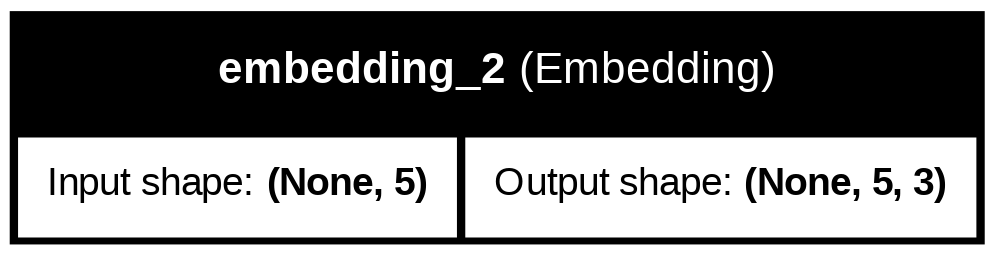

In [25]:
plot_model(model, show_shapes=True, show_layer_names=True)

## Model Compile

In [21]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Model Predict

When you write:

```python
Embedding(input_dim=17, output_dim=2, input_length=5)
```

the **`output_dim=2`** means **each word is represented by a vector with 2 numbers**, called an **embedding vector**.

---

# 🔹 What is an embedding vector?

* It’s a **dense numerical representation of a word**.
* Instead of using a word as a “token” (like 3, 7, 15…), the embedding gives it **a small vector that the model can learn**.
* These numbers are **learned during training**, so similar words end up with similar vectors.

Example:

| Word    | Token | Embedding (2-dim) |
| ------- | ----- | ----------------- |
| "cat"   | 3     | [0.25, 0.67]      |
| "dog"   | 7     | [0.30, 0.70]      |
| "apple" | 15    | [0.05, -0.12]     |

So `"cat"` is not just “3” anymore; it’s `[0.25, 0.67]` — a small 2-dimensional representation the model can work with.

---

# 🔹 Why embeddings are useful

1. **Continuous space** – model can measure similarity:

   ```python
   [0.25, 0.67] ≈ [0.30, 0.70]  → cat ≈ dog
   ```
2. **Dimensionality reduction** – instead of one-hot vectors of size 17, you just use size 2.
3. **Learnable representation** – these vectors are updated during training to improve model performance.

---

# 🔹 Visual analogy

Think of each word as a **point in 2D space** (because `output_dim=2`):

```
y
|
|          dog
|
|
|    cat
|
|
|                  apple
+------------------------> x
```

* Words close together → similar meaning in the context of your data.
* Words far apart → very different meanings.

---

In [22]:
model.predict(sequence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


array([[[-0.01976956, -0.03687489, -0.01975594],
        [-0.01801573, -0.04970146,  0.04511562],
        [ 0.00411428,  0.02501983, -0.01817495],
        [-0.03904941, -0.02125119,  0.02146463],
        [-0.03904941, -0.02125119,  0.02146463]],

       [[-0.04086284,  0.02391206,  0.03563093],
        [-0.04918013, -0.01760783, -0.00662015],
        [-0.0318776 ,  0.00886763,  0.03599842],
        [-0.03802854, -0.02806265, -0.04010558],
        [-0.03212365, -0.02954819, -0.02683768]],

       [[-0.01976956, -0.03687489, -0.01975594],
        [-0.03005859,  0.0492679 ,  0.01334608],
        [-0.00928243,  0.04199414,  0.00777328],
        [-0.01096766, -0.04896064,  0.01207446],
        [-0.03904941, -0.02125119,  0.02146463]],

       [[-0.04086284,  0.02391206,  0.03563093],
        [ 0.03140556,  0.00241756,  0.0441145 ],
        [-0.01527983, -0.03049889,  0.03553105],
        [-0.03904941, -0.02125119,  0.02146463],
        [-0.03904941, -0.02125119,  0.02146463]],

       [[-0.

In [27]:
model.predict(np.array([ 2, 22, 5, 23,  0]).reshape(1, -1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


array([[[-0.01976956, -0.03687489, -0.01975594],
        [-0.03201731, -0.04856068, -0.0451968 ],
        [ 0.00411428,  0.02501983, -0.01817495],
        [ 0.00089667, -0.0230149 , -0.017412  ],
        [-0.03904941, -0.02125119,  0.02146463]]], dtype=float32)